<center><h1>NYC Taxi Demand and Rider Behavior Analysis</h1></center>
<center><h3>January 1-14, 2023 case study using yellow taxi trip data</h3></center>

# Research Question
## Within a January 1-14, 2023 NYC yellow taxi sample, how do trip timing, location, and trip characteristics relate to demand, trip duration, fares, and tipping outcomes?

### Analysis components
1. Origin-destination network exploration
2. Time-of-day and weekday demand analysis
3. Tip likelihood baseline classification
4. Fare amount regression
5. Trip duration regression

### Scope note
The notebook filters the working dataset to January 1 through January 14, 2023. Findings should be interpreted as a short-window case study rather than a citywide annual analysis.

In [2]:
# Import necessary libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import networkx as nx
import folium
import sklearn
import seaborn as sns
import statsmodels.api as sm

In [3]:
# Read in and display first few rows of taxi traffic data set
df = pd.read_csv('taxi.csv', engine='python', on_bad_lines='skip')
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,total_amount
0,2,01/01/2023 12:00:00 AM,01/01/2023 12:08:00 AM,NaN,1.53,42,41,0,12.98,0.00,14.48
1,2,01/01/2023 12:00:05 AM,01/01/2023 12:26:27 AM,1.0,1.32,249,186,2,21.9,0.00,26.9
2,2,01/01/2023 12:00:06 AM,01/01/2023 12:05:44 AM,1.0,1.7,125,68,2,9.3,0.00,14.3
3,2,01/01/2023 12:00:08 AM,01/01/2023 12:11:24 AM,1.0,3.1,42,244,2,16.3,0.00,18.8
4,2,01/01/2023 12:00:09 AM,01/01/2023 12:15:10 AM,1.0,3.8,79,231,1,19.8,7.44,32.24


### Development note
Minor preprocessing and notebook-organization snippets were originally drafted with AI assistance during the course project. The final workflow shown here was reviewed, edited, and integrated into the notebook manually.

In [4]:
# Change date-time pickup and drop-off columns to a new, usable form
df['pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], format='%m/%d/%Y %I:%M:%S %p')
df['dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], format='%m/%d/%Y %I:%M:%S %p')

# Create new columns for pickup and drop-off times
df['month'] = df['pickup_datetime'].dt.month
df['pickup day'] = df['pickup_datetime'].dt.day
df['pickup hour'] = df['pickup_datetime'].dt.hour
df['pickup minute'] = df['pickup_datetime'].dt.minute
df['trip_duration_minutes'] = round((df['dropoff_datetime'] - df['pickup_datetime']).dt.total_seconds() / 60, 2)

# Insert new columns into specified locations within the data set 
cols = list(df.columns)
insert_pos = cols.index('tpep_pickup_datetime') + 1
for col in ['month', 'pickup day', 'pickup hour', 'pickup minute', 'trip_duration_minutes']:
    cols.insert(insert_pos, cols.pop(cols.index(col)))
    insert_pos += 1

# Drop unnecessary columns and shorten data set due to its many rows
df = df[cols]
df.drop(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'dropoff_datetime'], axis=1, inplace=True)
df = df[(df['pickup day'] <= 14) & (df['month'] == 1)]

In [5]:
# Display data
display(df.head())
display(df.tail())

,month,pickup day,pickup hour,pickup minute,trip_duration_minutes,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,total_amount,pickup_datetime
0,1,1,0,0,8.00,NaN,1.53,42,41,0,12.98,0.00,14.48,2023-01-01 00:00:00
1,1,1,0,0,26.37,1.0,1.32,249,186,2,21.9,0.00,26.9,2023-01-01 00:00:05
2,1,1,0,0,5.63,1.0,1.7,125,68,2,9.3,0.00,14.3,2023-01-01 00:00:06
3,1,1,0,0,11.27,1.0,3.1,42,244,2,16.3,0.00,18.8,2023-01-01 00:00:08
4,1,1,0,0,15.02,1.0,3.8,79,231,1,19.8,7.44,32.24,2023-01-01 00:00:09


,month,pickup day,pickup hour,pickup minute,trip_duration_minutes,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,total_amount,pickup_datetime
1343542,1,14,23,59,24.53,3.0,5.2,234,87,2,26.1,0.00,31.1,2023-01-14 23:59:58
1343543,1,14,23,59,4.77,0.0,0.7,263,239,1,5.8,1.00,11.8,2023-01-14 23:59:59
1343544,1,14,23,59,4.55,1.0,1.1,236,75,1,7.2,2.40,14.6,2023-01-14 23:59:59
1343545,1,14,23,59,13.43,1.0,1.92,234,79,1,14.2,2.00,21.2,2023-01-14 23:59:59
1343546,1,14,23,59,14.55,NaN,4.56,90,151,0,25.14,5.83,34.97,2023-01-14 23:59:59


# 1. Origin-Destination Route Exploration

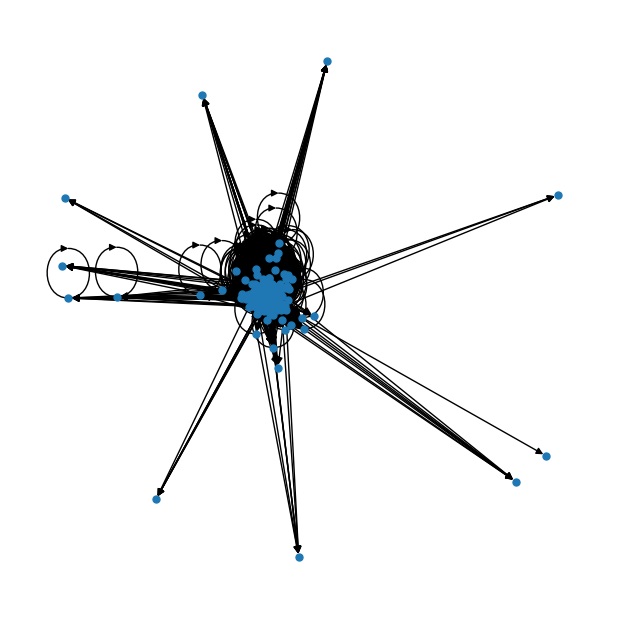

In [6]:
# Initialize an empty directed graph
G = nx.DiGraph()

# Add an edge for each trip from its pickup location to its drop-off location
for i in range(len(df['PULocationID'])):
    G.add_edge(df['PULocationID'][i], df['DOLocationID'][i])

# Set figure size
plt.figure(figsize=(6, 6))

# Determine node positions with a spring layout and draw the graph with small nodes
pos = nx.spring_layout(G, seed=67)
nx.draw(G, pos, node_size=25)

# Display figure
plt.show()

In [7]:
# Group trips by their pickup and drop-off locations and record number of occurrences for each combination
trip_counts = df.groupby(['PULocationID', 'DOLocationID']).size()

# Sort aggregated data in descending order and reset index for easier access in the future
popular_routes = trip_counts.sort_values(ascending=False).reset_index(name='count')

# Display the top 20 most popular routes and their count
display(popular_routes.head(20))

,PULocationID,DOLocationID,count
0,237,236,9584
1,236,237,8166
2,264,264,6628
3,236,236,6520
4,237,237,5923
5,237,161,4033
6,161,237,3882
7,161,236,3731
8,239,238,3611
9,141,236,3586


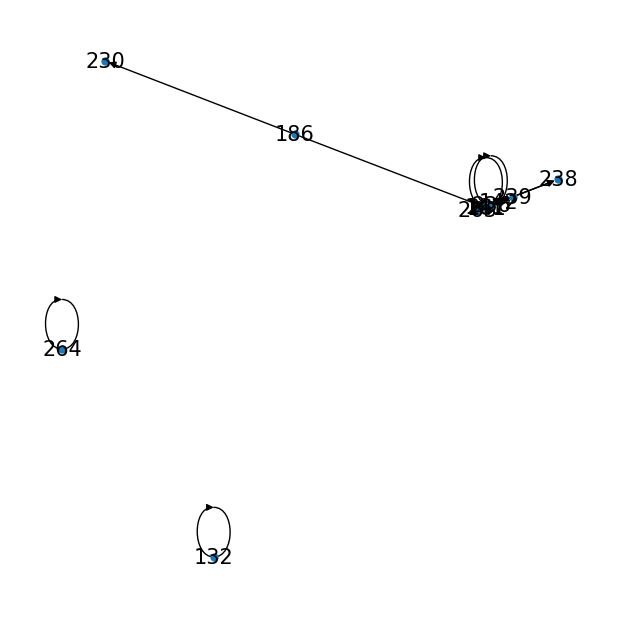

In [8]:
# Initialize a new directed graph
G_popular = nx.DiGraph()

# Add edge between 20 most popular routes
for i in range(0,20):
    G_popular.add_edge(popular_routes['PULocationID'][i], popular_routes['DOLocationID'][i], weight = popular_routes['count'][i])

plt.figure(figsize=(6, 6))

# Determine node positions with a spring layout
pos = nx.spring_layout(G_popular, seed=67)

# Draw the graph using small nodes, spring layout locations, and node ID labels
nx.draw(G_popular, pos, node_size=25, with_labels=True, font_size=15)

plt.show()

In [9]:
# Read in and display new data set 
zones = pd.read_csv("taxi_zones.csv")
display(zones.head())
display(zones.tail())

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


,LocationID,Borough,Zone,service_zone
260,261,Manhattan,World Trade Center,Yellow Zone
261,262,Manhattan,Yorkville East,Yellow Zone
262,263,Manhattan,Yorkville West,Yellow Zone
263,264,Unknown,NaN,NaN
264,265,NaN,Outside of NYC,NaN


### Visualization note
Legend formatting for the network graph was refined during drafting to improve readability for zone labels.

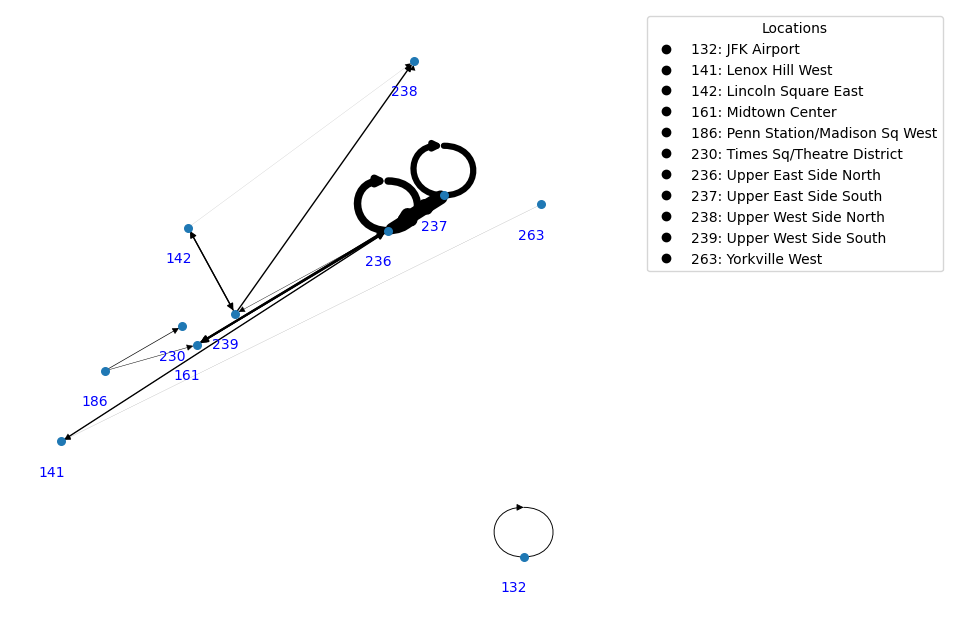

In [10]:
# Initialize an empty dictionary 
zone_dict = {}

# Drop routes connection to Location ID of 264 and 265 as these locations are either unknown, or outside of NYC
popular_routes_cleaned = popular_routes[(popular_routes['PULocationID'] != 264) & (popular_routes['PULocationID'] != 265)]

# Concatenate pickup and drop-off ID lists
# Use .unique to return an array containing each ID present in the top 20 popular routes
popular_IDs_cleaned = pd.concat([popular_routes_cleaned['PULocationID'].head(20), popular_routes_cleaned['DOLocationID'].head(20)]).unique()

# Reset index for easier access in the future
popular_routes_cleaned = popular_routes_cleaned.reset_index(drop=True)

# Add each Location ID and its corresponding real-world zone name to dictionary
for i in range(len(zones['LocationID'])):
    if zones['LocationID'][i] in popular_IDs_cleaned:
        key = zones['LocationID'][i]
        value = zones['Zone'][i]
        zone_dict[key] = value

# Create a dictionary containing actual geographical coordinates of each zone/ID for graphing (longitude & latitude)
pos = {
    132: (-73.9500,40.7200), #This is JFK Airport. Coordinates are adjusted for graph cohesion (don't match real-world location)
    141: (-73.9981,40.7390),
    142: (-73.9849,40.7742),
    161: (-73.9840,40.7549),
    186: (-73.9936,40.7506),
    230: (-73.9855,40.7580),
    236: (-73.9641,40.7737),
    237: (-73.9583,40.7795),
    238: (-73.9614,40.8016),
    239: (-73.9800,40.7600),
    263: (-73.9482,40.7780)}

# Initialize a new directed graph
G_popular = nx.DiGraph()

# Add edge between 20 most popular routes weighted by the number of occurrences
for i in range(0,20):
    G_popular.add_edge(popular_routes_cleaned['PULocationID'][i], popular_routes_cleaned['DOLocationID'][i], weight = popular_routes_cleaned['count'][i])

# Extract the weight values from directed graph
weights = np.array(list(nx.get_edge_attributes(G_popular, 'weight').values()))

# Normalize the weights in order to create a visible graph
weights_norm = (weights - weights.min()) / (weights.max() - weights.min())

# Scale the weights in order to see a larger visual differences between routes
weights_norm = weights_norm * 10

# Initialize a dictionary to store label positions
label_pos = {}

# Access location IDs and positions from pos dictionary
# Add each ID to new dictionary in addition to slightly adjusted label locations
for key, value in pos.items():
    label_pos[key] = (value[0] -0.001, value[1] - 0.005)
    
plt.figure(figsize=(6, 6))

# Draw the graph using small nodes, geographical coordinates, weights, and labels
nx.draw(G_popular, pos, node_size=30, width = weights_norm, with_labels=False, font_size=15)

# Draw all of the corresponding node labels using the label_pos dictionary
nx.draw_networkx_labels(G_popular, label_pos, font_size=10, font_color='blue')

# Initialize empty labels list
legend_handles = []

# Add location IDs and their corresponding zone name
for node_id, name in zone_dict.items():
    label = f"{node_id}: {name}"
    
    # Create an invisible line plot for the legend entry
    line, = plt.plot([], [], marker="o", color="black", linestyle='None', label=label)
    legend_handles.append(line)

# Display the legend
plt.legend(handles=legend_handles, title="Locations", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


### Mapping note
The folium section was exploratory and is kept as a supplemental visualization rather than a core modeling result.

In [11]:
# Re-establish geographical coordinate dictionary with every location having proper coordinates
pos = {
    132: (-73.7797,40.6446),
    141: (-73.9981,40.7390),
    142: (-73.9849,40.7742),
    161: (-73.9840,40.7549),
    186: (-73.9936,40.7506),
    230: (-73.9855,40.7580),
    236: (-73.9641,40.7737),
    237: (-73.9583,40.7795),
    238: (-73.9614,40.8016),
    239: (-73.9800,40.7600),
    263: (-73.9482,40.7780)}

# Initialize a folium map with included starting location
map_nyc = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# Add nodes to the map using coordinates in pos dictionary, and labels in zone_dict dictionary
for node_id, coords in pos.items():
    lat, lon = coords[1], coords[0] 
    zone_name = zone_dict.get(node_id, "Unknown")
    folium.Marker(location=[lat, lon], popup=f"{node_id}: {zone_name}").add_to(map_nyc)

# Loop over starting and ending nodes in previous graph
for start_node, end_node in G_popular.edges():

    # Save geographical coordinates of each node in a new variable
    start_coords = pos.get(start_node)
    end_coords = pos.get(end_node)

    # Unpack each the coordinates of each node (unpack latitude and longitude)
    start_lat, start_lon = start_coords[1], start_coords[0]
    end_lat, end_lon = end_coords[1], end_coords[0]

    # Create a list of the start and end coordinates to define the path
    locations = [[start_lat, start_lon], [end_lat, end_lon]]

    # Add segment/edge connecting starting and ending locations
    folium.PolyLine(locations=locations, color='blue', weight=3).add_to(map_nyc)

map_nyc

# 2. Time-of-Day Demand Analysis

### Hourly Demand By Hour Of Day

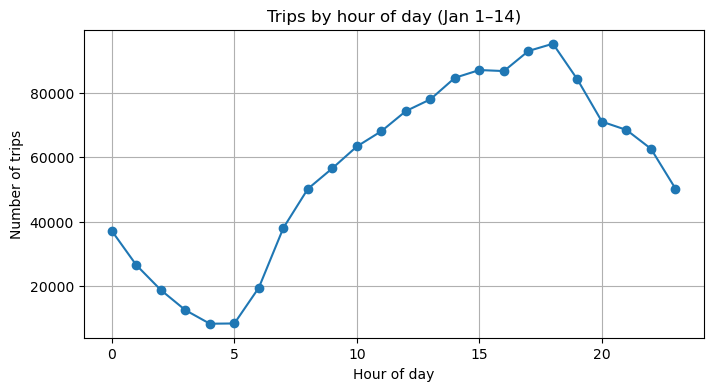

In [12]:
df2 = df.copy()

df2['day_of_week'] = df2['pickup_datetime'].dt.day_name()
df2['date'] = df2['pickup_datetime'].dt.date
df2['is_weekend'] = df2['day_of_week'].isin(['Saturday', 'Sunday'])

# Overall hourly demand 
hourly_counts = df.groupby('pickup hour').size()
plt.figure(figsize=(8, 4))
hourly_counts.plot(kind='line', marker='o')
plt.xlabel('Hour of day')
plt.ylabel('Number of trips')
plt.title('Trips by hour of day (Jan 1–14)')
plt.grid(True)
plt.show()

The hourly demand plot shows a clear within-day usage pattern in this January sample. Trip counts are lowest during the overnight hours, rise during the morning commute window, and increase again in the late afternoon and early evening. That pattern is consistent with commuting and routine daytime travel, although the chart alone cannot identify the specific purpose of each trip.

### Weekday vs. Weekend Pattern

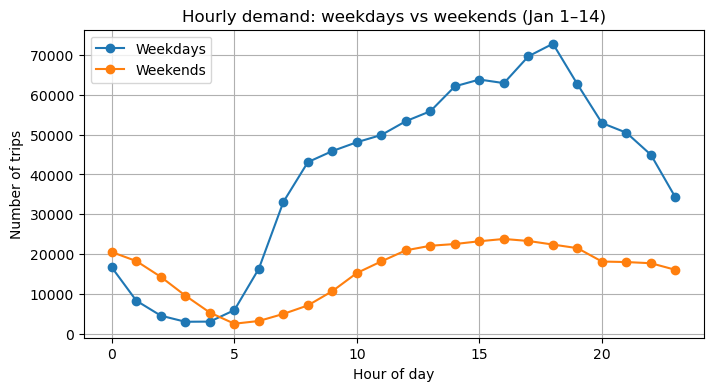

In [13]:
# Weekday vs weekend pattern
hourly_weekday = df2[~df2['is_weekend']].groupby('pickup hour').size()
hourly_weekend = df2[df2['is_weekend']].groupby('pickup hour').size()

plt.figure(figsize=(8, 4))
plt.plot(hourly_weekday.index, hourly_weekday.values, marker='o', label='Weekdays')
plt.plot(hourly_weekend.index, hourly_weekend.values, marker='o', label='Weekends')
plt.xlabel('Hour of day')
plt.ylabel('Number of trips')
plt.title('Hourly demand: weekdays vs weekends (Jan 1–14)')
plt.legend()
plt.grid(True)
plt.show()

Comparing weekdays and weekends shows that weekday demand is more concentrated around commuting hours, while weekend demand is flatter and extends later into the day. This is consistent with a shift from routine work travel toward more flexible discretionary travel, but that interpretation should be treated as suggestive rather than definitive because the dataset does not contain trip purpose.

### Hour and Day-of-Week Pattern

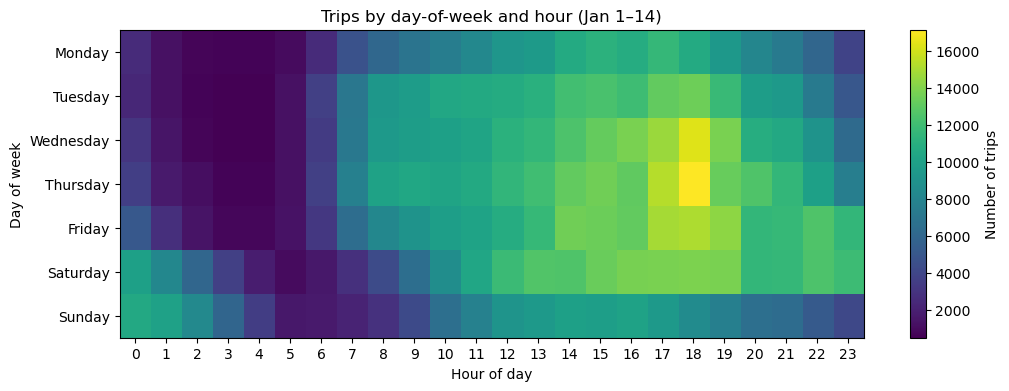

In [14]:
# Hour and day-of-week 
pivot = df2.groupby(['day_of_week', 'pickup hour']).size().unstack(fill_value=0)

# Put days in order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(day_order)

plt.figure(figsize=(12, 4))
plt.imshow(pivot, aspect='auto')
plt.colorbar(label='Number of trips')
plt.xticks(ticks=np.arange(len(pivot.columns)), labels=pivot.columns)
plt.yticks(ticks=np.arange(len(pivot.index)), labels=pivot.index)
plt.xlabel('Hour of day')
plt.ylabel('Day of week')
plt.title('Trips by day-of-week and hour (Jan 1–14)')
plt.show()


The heatmap reinforces the timing pattern seen in the line charts. Weekdays show stronger afternoon and early evening peaks, while weekends maintain broader midday and evening activity. Because the notebook covers only two weeks in January, these differences should be read as short-horizon temporal patterns rather than stable year-round seasonal behavior.

### Daily Demand Across the January 1-14 Window

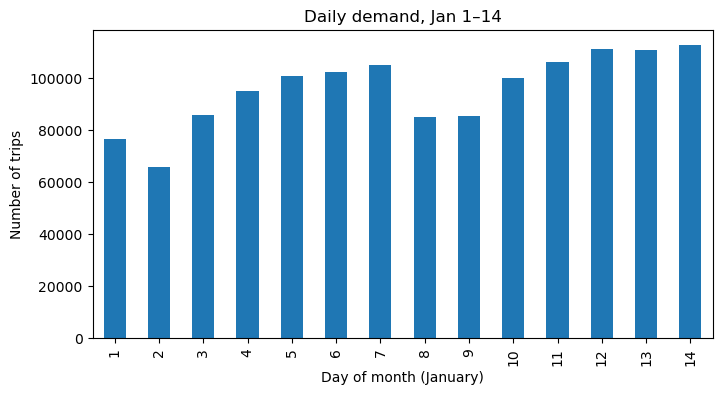

In [15]:
# Daily totals over Jan 1-14 
daily_counts = df2.groupby('pickup day').size()
plt.figure(figsize=(8, 4))
daily_counts.plot(kind='bar')
plt.xlabel('Day of month (January)')
plt.ylabel('Number of trips')
plt.title('Daily demand, Jan 1–14')
plt.savefig("daily_totals.png", dpi=300, bbox_inches='tight')
plt.show()

The daily totals increase over much of the January 1-14 window, with lower counts at the beginning of the period and higher counts near the end. A reasonable interpretation is that the first few days of January reflect post-holiday behavior and then move toward more typical activity levels. However, this pattern could also be influenced by weekday mix, weather, or sample construction, so it should not be treated as a general trend for the full month.

## 3. Tip Likelihood Baseline Classification

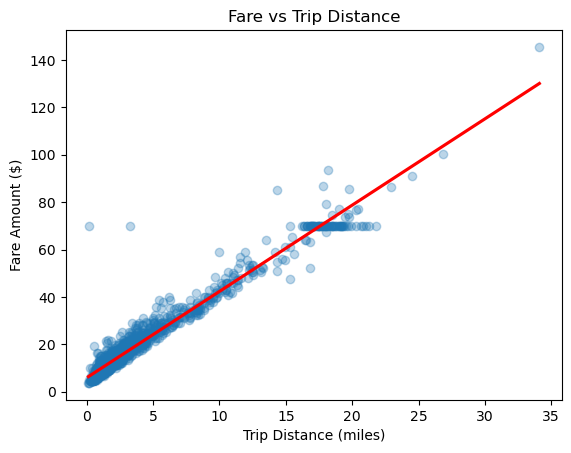

In [16]:
# Load data
df3 = df.copy()

# Convert to numeric FIRST
df3["trip_distance"] = pd.to_numeric(df3["trip_distance"], errors="coerce")
df3["fare_amount"]   = pd.to_numeric(df3["fare_amount"], errors="coerce")

# Drop rows that are missing or invalid
df3 = df3[["trip_distance", "fare_amount"]].dropna()
df3 = df3[(df3["trip_distance"] > 0) & (df3["fare_amount"] > 0)]

# Small sample for speed
sample = df3.sample(1500, random_state=0)

# Plot
sns.regplot(
    data=sample,
    x="trip_distance",
    y="fare_amount",
    ci=None,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title("Fare vs Trip Distance")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.show()

The distance-fare plot shows a strong positive association between trip distance and fare amount in the sampled trips. The relationship appears close to linear over most of the range, which makes trip distance a useful explanatory variable for fare modeling. That said, the scatter also shows dispersion and outliers, so the plot should be interpreted as an empirical relationship rather than a complete pricing rule.

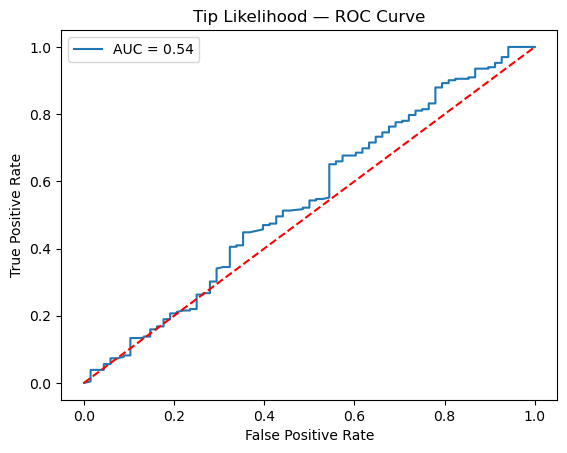

In [17]:
# Load and clean
df3 = pd.read_csv("taxi.csv", low_memory=False)
df3 = df3[["trip_distance", "fare_amount", "passenger_count", "tip_amount"]].dropna()
df3["tipped"] = (df3["tip_amount"] > 0).astype(int)

# Small sample
df3 = df3.sample(1500, random_state=0)

# Model
X = df3[["trip_distance", "fare_amount", "passenger_count"]]
y = df3["tipped"]
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2)

model = sklearn.linear_model.LogisticRegression(max_iter=500).fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, _ = sklearn.metrics.roc_curve(y_test, y_prob)
auc_val = sklearn.metrics.auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {auc_val:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tip Likelihood — ROC Curve")
plt.legend()
plt.show()

The ROC curve indicates that this baseline logistic regression has weak predictive value. An AUC near 0.54 is only slightly above random guessing, which suggests the current feature set does not explain tipping behavior well. The result is still useful because it shows the difference between an explanatory feature relationship and a model that is strong enough for prediction.

## 4. Fare Amount Regression

In [22]:
## Some columns are of type object
df4 = df.copy()

for col in ['trip_distance', 'fare_amount', 'total_amount']:
  df4[col] = pd.to_numeric(df4[col], errors='coerce')

In [24]:
### FARE PREDICTION REGRESSION

data = df4.drop(columns=['tip_amount', 'total_amount'])
data = data.select_dtypes(include=['number'])
data = data.dropna()

X = data.drop(columns=['fare_amount'])
y = data['fare_amount']

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                 4.627e+05
Date:                Mon, 24 Nov 2025   Prob (F-statistic):               0.00
Time:                        13:00:11   Log-Likelihood:            -4.7505e+06
No. Observations:             1312106   AIC:                         9.501e+06
Df Residuals:                 1312096   BIC:                         9.501e+06
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
month                     9.94

In [25]:
## STRONG MULTICOLLINEARITY DETECTED

columns = ["trip_distance", "trip_duration_minutes", "payment_type", "DOLocationID", "passenger_count", "month", "pickup day", "pickup hour", "pickup minute"]
X = data[columns]

X_const = sm.add_constant(X)

model = sm.OLS(y, X_const)
results = model.fit()

col_copy = columns.copy()
res = {}

for col in col_copy:
    a = X.drop(columns = col)
    X_temp = sm.add_constant(a)
    model_temp = sm.OLS(y, X_temp)
    results_temp = model_temp.fit()
    res[col] = results_temp.rsquared

final_cols = []

while len(final_cols) < 4:
    final_cols.append(min(res, key=res.get))
    res.pop(min(res, key=res.get))

print("Final columns:", final_cols)
print(results.summary())

Final columns: ['trip_distance', 'payment_type', 'trip_duration_minutes', 'passenger_count']
                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                 5.205e+05
Date:                Mon, 24 Nov 2025   Prob (F-statistic):               0.00
Time:                        13:00:19   Log-Likelihood:            -4.7506e+06
No. Observations:             1312106   AIC:                         9.501e+06
Df Residuals:                 1312097   BIC:                         9.501e+06
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

<Axes: >

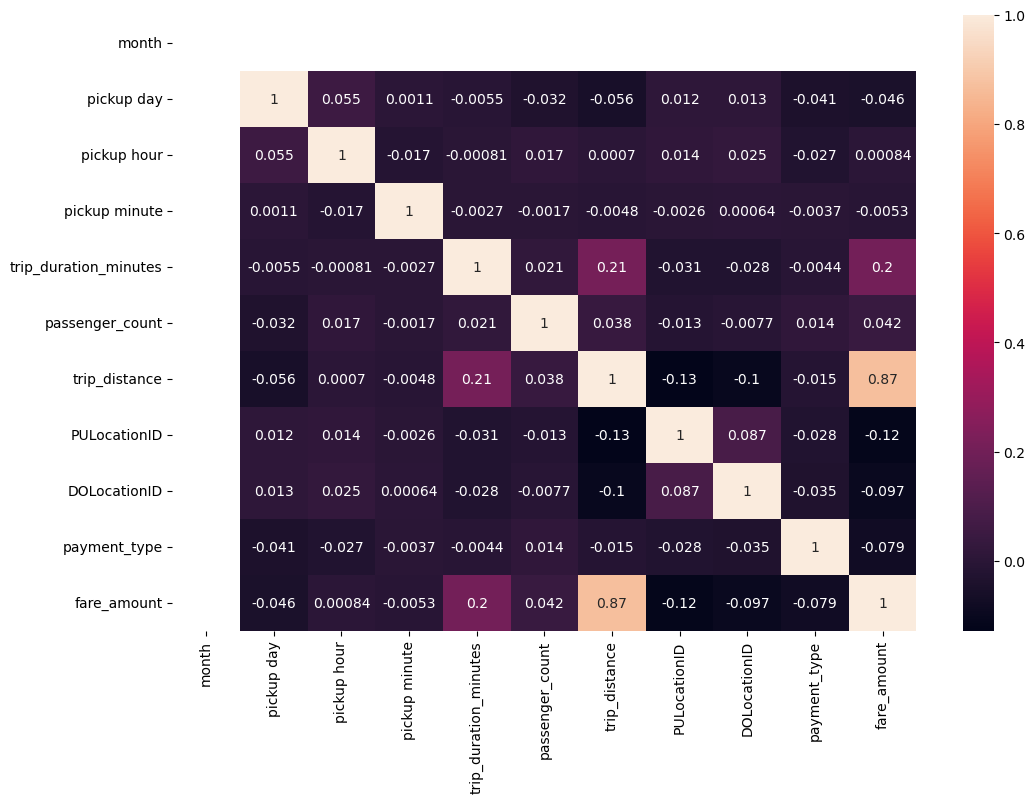

In [26]:
corr_matrix = data.corr()
plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix, annot=True)

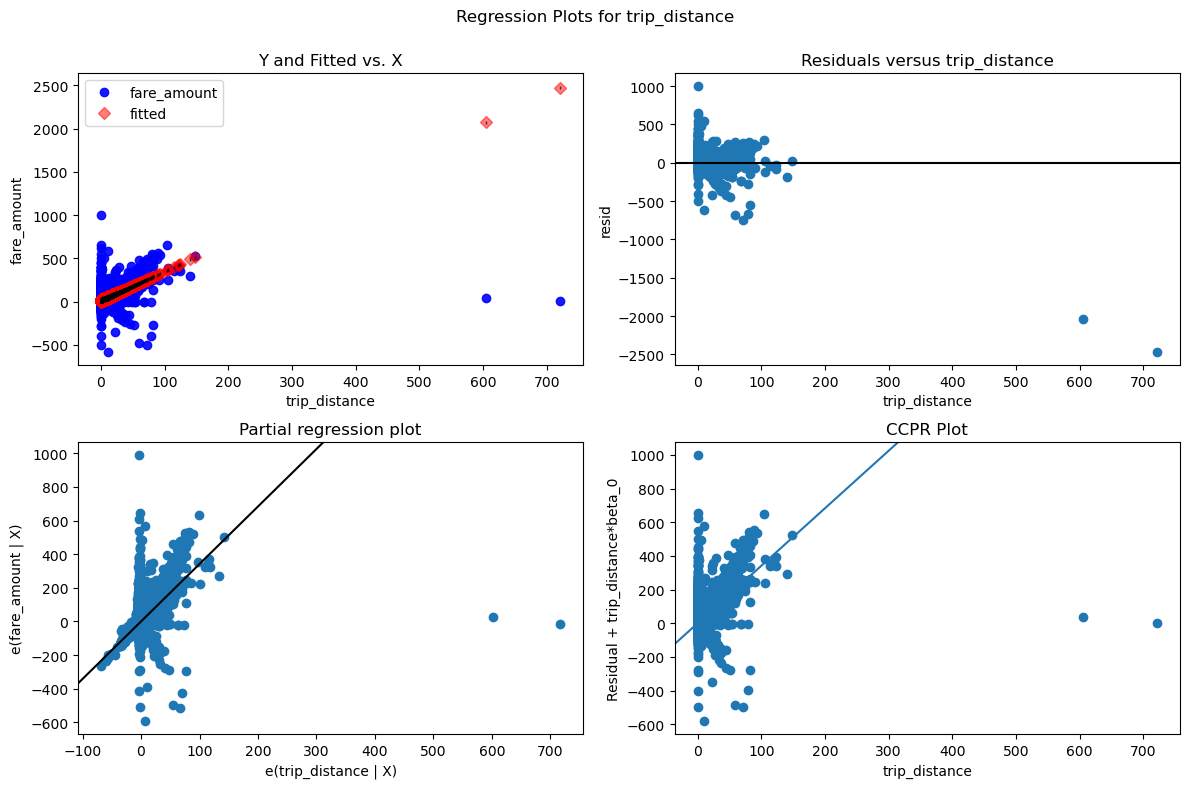

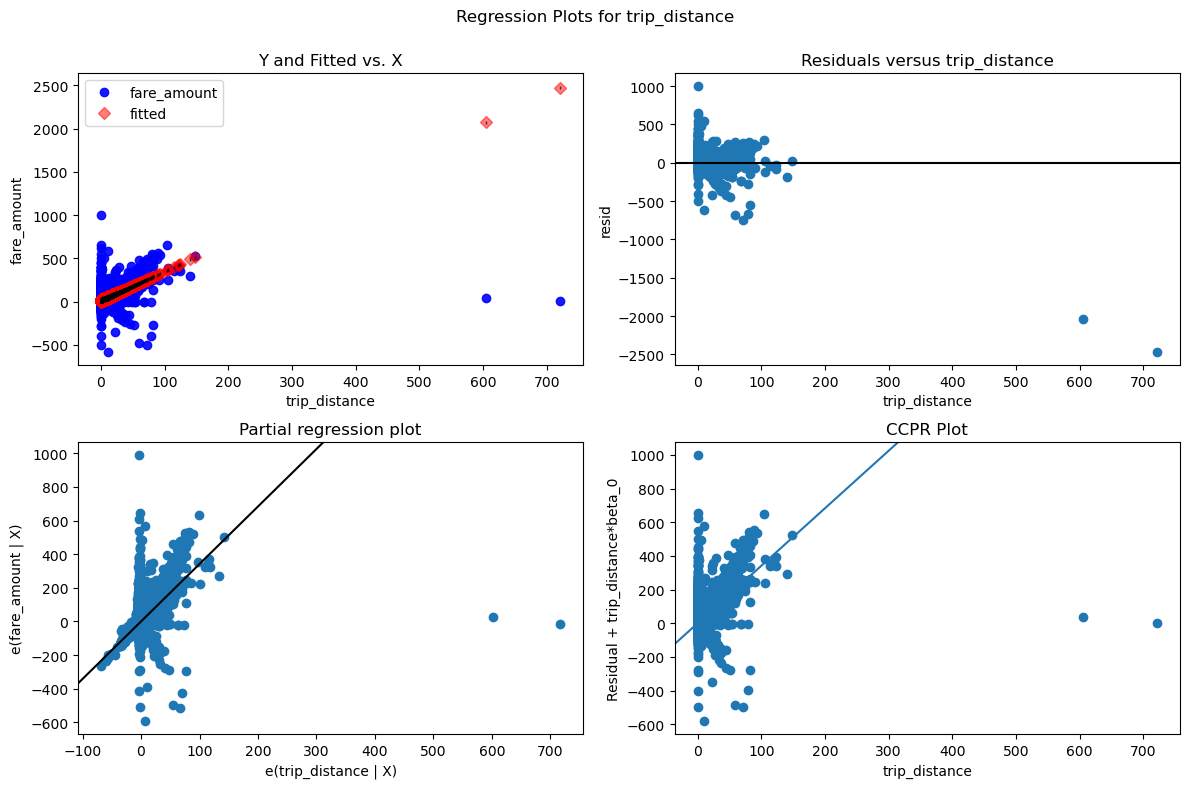

In [27]:
sm.graphics.plot_regress_exog(results, "trip_distance", fig=plt.figure(figsize=(12,8)))

In [28]:
data = data[data["trip_distance"] < 200]
X = data[final_cols]

y = data['fare_amount']

X_const = sm.add_constant(X)

model = sm.OLS(y, X_const)
results = model.fit()

print(results.summary())


                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                 1.190e+06
Date:                Mon, 24 Nov 2025   Prob (F-statistic):               0.00
Time:                        13:02:29   Log-Likelihood:            -4.6828e+06
No. Observations:             1312104   AIC:                         9.366e+06
Df Residuals:                 1312099   BIC:                         9.366e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     8.84

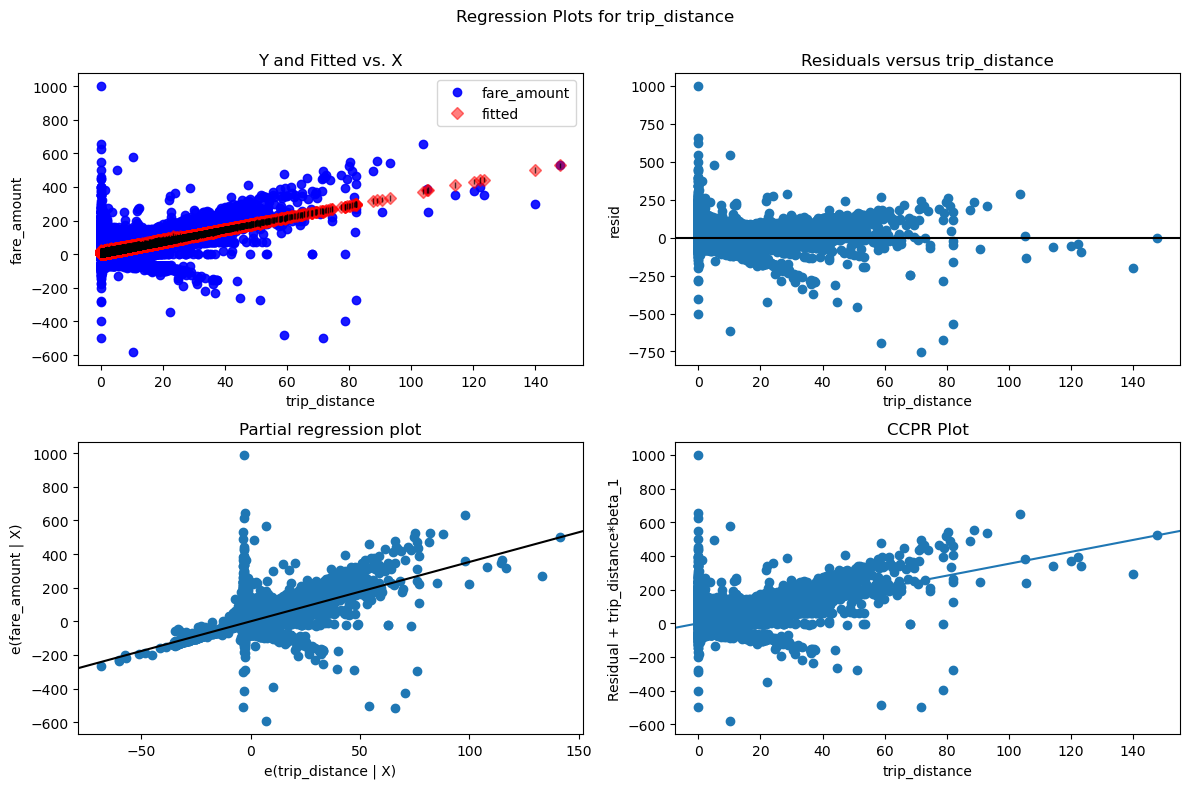

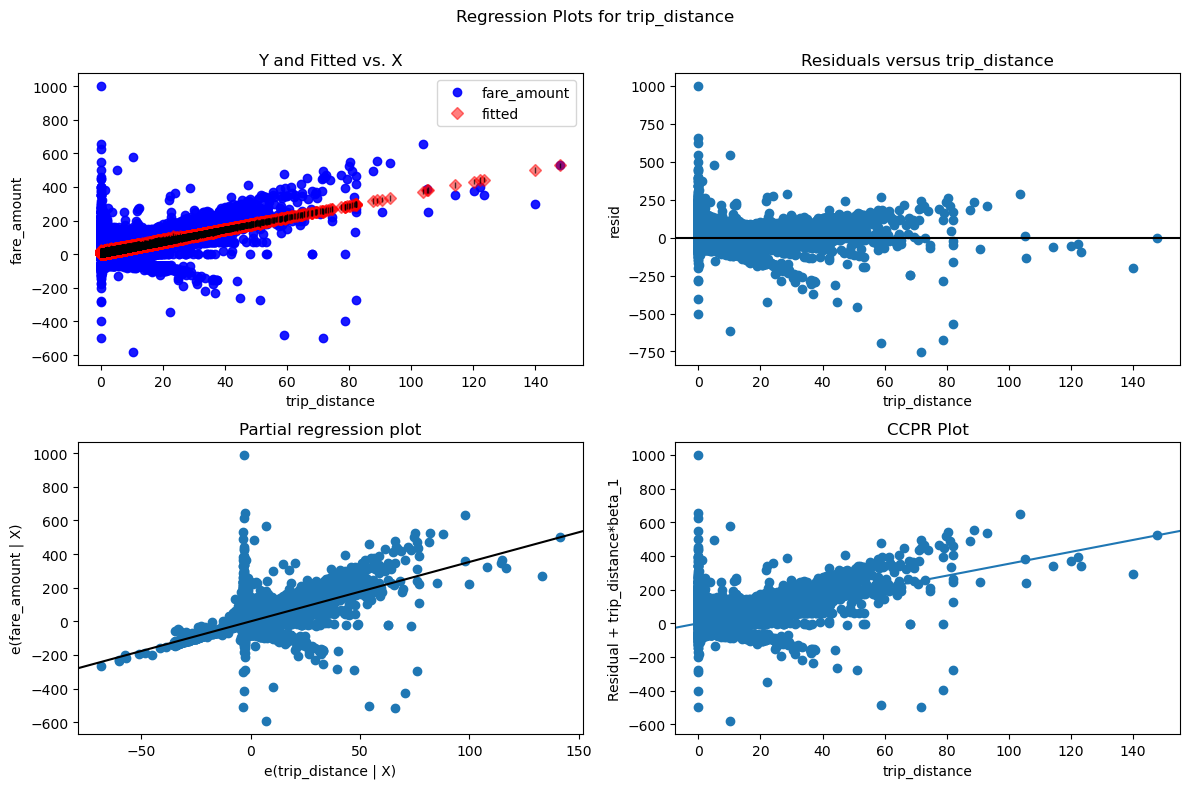

In [29]:
sm.graphics.plot_regress_exog(results, "trip_distance", fig=plt.figure(figsize=(12,8)))


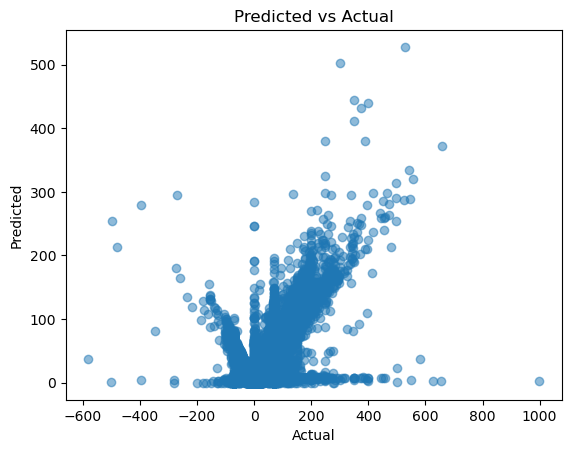

In [30]:
y_pred = results.predict(X_const)

plt.scatter(y, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

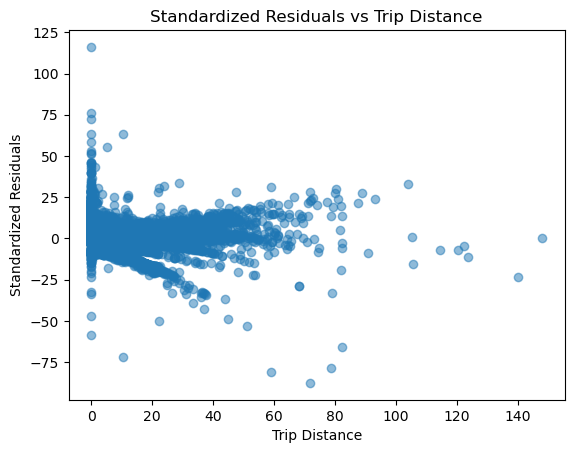

In [31]:
residuals = y - y_pred
std_resid = residuals / residuals.std() 
plt.scatter(X["trip_distance"], std_resid, alpha=0.5)
plt.xlabel("Trip Distance")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs Trip Distance")
plt.show()


## 5. Trip Duration Regression

### Data cleaning and feature setup
This section creates a modeling dataset for trip duration by converting distance to numeric form, removing missing values, and filtering out invalid or implausible trips. These choices make the regression more interpretable, but they also mean the model reflects a cleaned subset rather than every raw trip record.

In [33]:
df5 = df.copy()

df5["trip_distance"] = pd.to_numeric(df5["trip_distance"], errors="coerce")

df5 = df5.dropna(subset=["trip_duration_minutes","trip_distance","passenger_count"])
df5 = df5[df5["trip_duration_minutes"] > 0]
df5 = df5[df5["trip_duration_minutes"] <= 120]
df5 = df5[df5["trip_distance"] > 0]

X = df5[["trip_distance","pickup hour","pickup day","pickup minute","passenger_count"]]
y = df5["trip_duration_minutes"]

### Baseline regression fit and interpretation

This code splits the cleaned dataset into training and test sets, fits a linear regression model, and reports the held-out R-squared value together with the intercept and coefficients.

- The R-squared value summarizes how much variation in trip duration is explained on the test split by this linear specification.
- The coefficients are useful for directional interpretation, but they should not be treated as causal effects.
- Because the model uses simple linear terms and limited features, it is better described as a baseline explanatory model than as a production-grade trip-time predictor.

In [34]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=0)

model = sklearn.linear_model.LinearRegression()
model.fit(X_train, y_train)

r2 = model.score(X_test, y_test)

print("R^2:", r2)
print("Intercept (minutes):", model.intercept_)
print("Coefficients (minutes per unit):")
print(pd.Series(model.coef_, index=X.columns))

R^2: 0.6205825204940071
Intercept (minutes): 6.251997642248313
Coefficients (minutes per unit):
trip_distance      1.953015
pickup hour        0.022181
pickup day         0.114734
pickup minute     -0.002409
passenger_count    0.107822
dtype: float64


### Plotting setup for partial effect visualizations

The variables below are used to draw simplified regression lines for each feature while holding the remaining predictors at their median values. These charts are helpful for interpretation, but they are visual summaries of a linear model rather than independent evidence that each feature acts alone.

In [35]:
df_filter = df5[df5["trip_distance"] <= 300]

features = ["trip_distance","pickup hour","pickup day","pickup minute","passenger_count"]
titles = {"trip_distance":"Trip Distance (Miles)", "pickup hour":"Pickup Hour", "pickup day":"Pickup Day",
          "pickup minute":"Pickup Minute", "passenger_count":"Passenger Count"}

coefs = pd.Series(model.coef_, index=features)
meds = df_filter[features].median()
inter = model.intercept_

### Visualizing fitted linear trends against observed data

Each plot overlays observed trip durations with the fitted line implied by the regression model for one predictor at a time. This makes the linear trend easier to inspect, but the figures should be read as model-based summaries rather than proof that the true relationship is strictly linear across the full feature range.

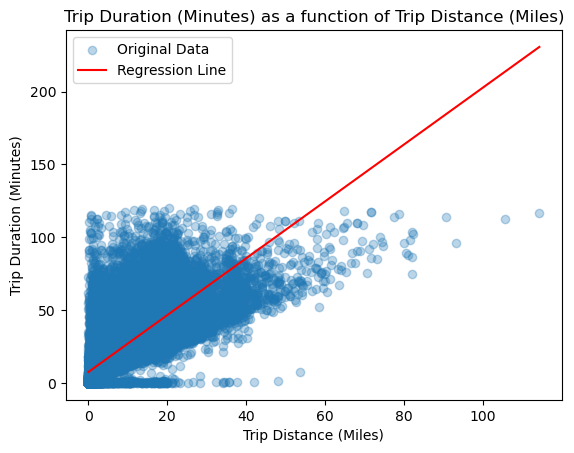

C:\Users\gunna\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


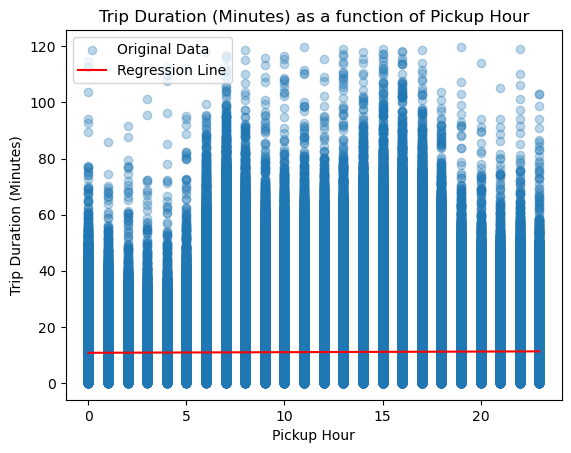

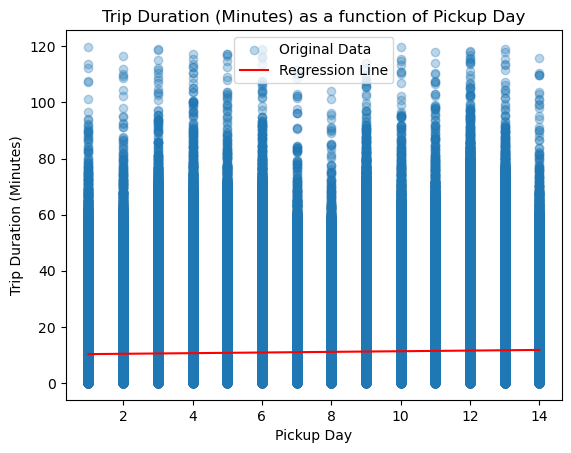

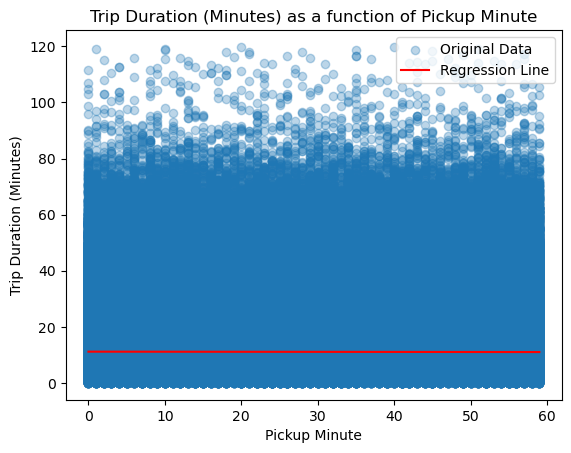

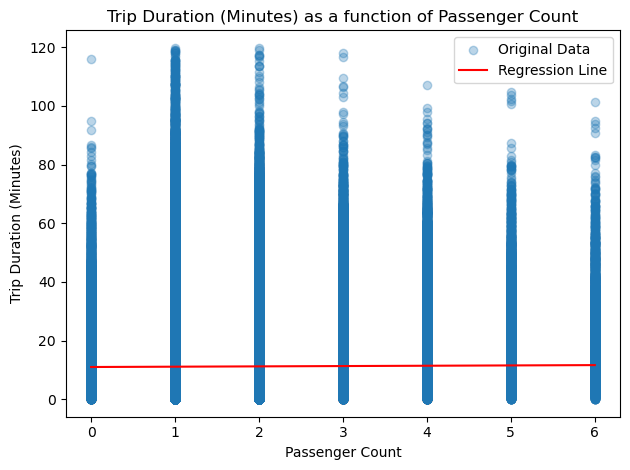

In [36]:
for feat in features:
    const_part = inter + (coefs.drop(feat) * meds.drop(feat)).sum()
    slope = coefs[feat]

    x_data = df_filter[feat]
    y_data = df_filter["trip_duration_minutes"]

    x_line = np.linspace(x_data.min(), x_data.max(), 200)
    y_line = const_part + slope * x_line

    plt.figure()
    plt.scatter(x_data, y_data, alpha=0.3, label="Original Data")
    plt.plot(x_line, y_line, color="red", label="Regression Line")
    plt.xlabel(titles[feat])
    plt.ylabel("Trip Duration (Minutes)")
    plt.title(f"Trip Duration (Minutes) as a function of {titles[feat]}")
    plt.legend()

plt.tight_layout()
plt.show()